# Machine Learning project autumn 2024

Authors: Dimitar Kochev, Mihael Stoyanov <br>

Reqired imports:



In [189]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from functools import partial
import tensorflow as tf
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten,Conv2D, MaxPooling2D, Dropout, BatchNormalization 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix
import pickle
from sklearn.model_selection import GridSearchCV
from collections import Counter


# Exploratory data analysis

### Load data:

In [3]:
train_data = np.load('Data+Description\\fashion_train.npy')
test_data = np.load('Data+Description\\fashion_test.npy')

In [4]:
# Devide features and labels
train_data_X=train_data[:,:-1]
train_data_y=train_data[:,-1]
#norm_train_data_X=train_data_X / 255.0 #Scale pixel values to [0, 1]
test_data_X=test_data[:,:-1]
test_data_y=test_data[:,-1]
#norm_test_data_X=test_data_X / 255.0

## Visualisations
### Distribution of classes in train set

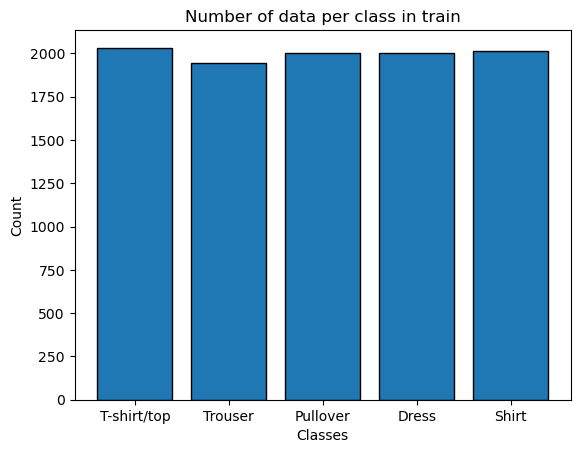

In [5]:
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']

# Plot the histogram
plt.hist(train_data_y, bins=np.arange(6)-0.5, edgecolor='black', rwidth=0.8)

# Set the x-ticks to the class names
plt.xticks(ticks=np.arange(5), labels=categories)

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('Number of data per class in train')

# Show the plot
plt.show()

### Dimensionality reduction with PCA

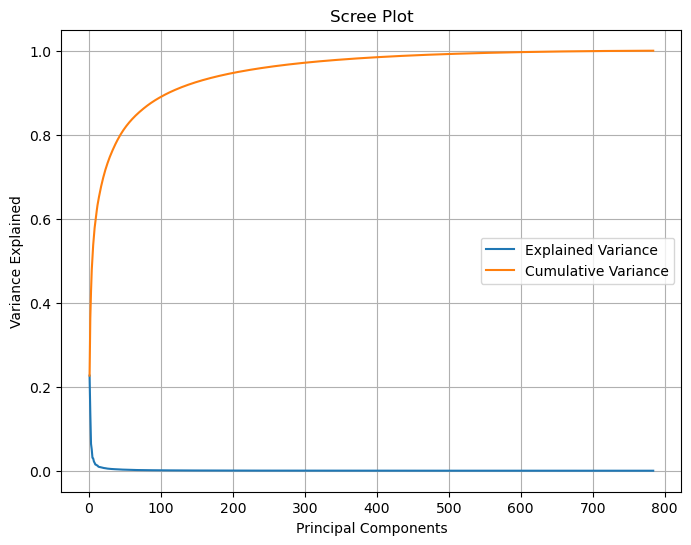

In [7]:
#PCA on whole data

scaler = StandardScaler()
image_scaled = scaler.fit_transform(train_data_X)

# Apply PCA
pca = PCA()
pca.fit(image_scaled)

# Scree plot - Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, label='Explained Variance')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, label='Cumulative Variance')
plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Class distribution in 2 components space

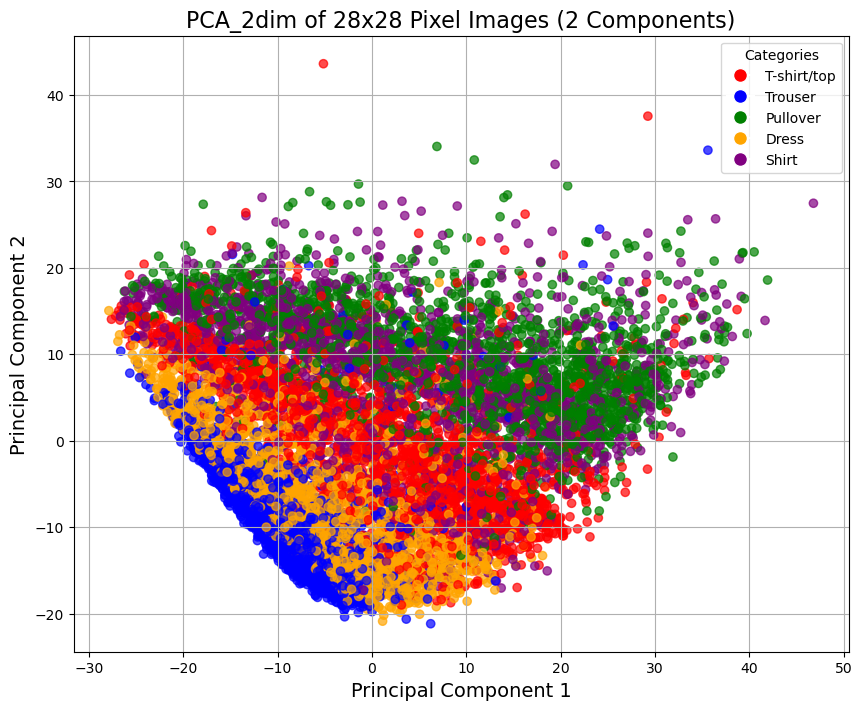

In [8]:
X_scaled = scaler.fit_transform(train_data_X)
pca_2dim = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
principal_components = pca_2dim.fit_transform(X_scaled)

# Step 6: Convert to DataFrame for easier plotting
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 7: Define colors for each category
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colors corresponding to categories

# Map the categories to colors
color_map = {i: colors[i] for i in range(len(categories))}
point_colors = [color_map[int(label)] for label in train_data_y]  # Assign colors based on the labels

# Step 8: Visualize the PCA_2dim results in 2D
plt.figure(figsize=(10, 8))
plt.scatter(principal_df['PC1'], principal_df['PC2'], 
            alpha=0.7, c=point_colors)

# Labels and title
plt.title('PCA_2dim of 28x28 Pixel Images (2 Components)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)

# Create a legend
import matplotlib.lines as mlines
legend_handles = [mlines.Line2D([], [], marker='o', color='w', 
                                  label=categories[i], 
                                  markerfacecolor=colors[i], 
                                  markersize=10) for i in range(len(categories))]
plt.legend(handles=legend_handles, title='Categories')

plt.grid()
plt.show()


Example for an image with different components

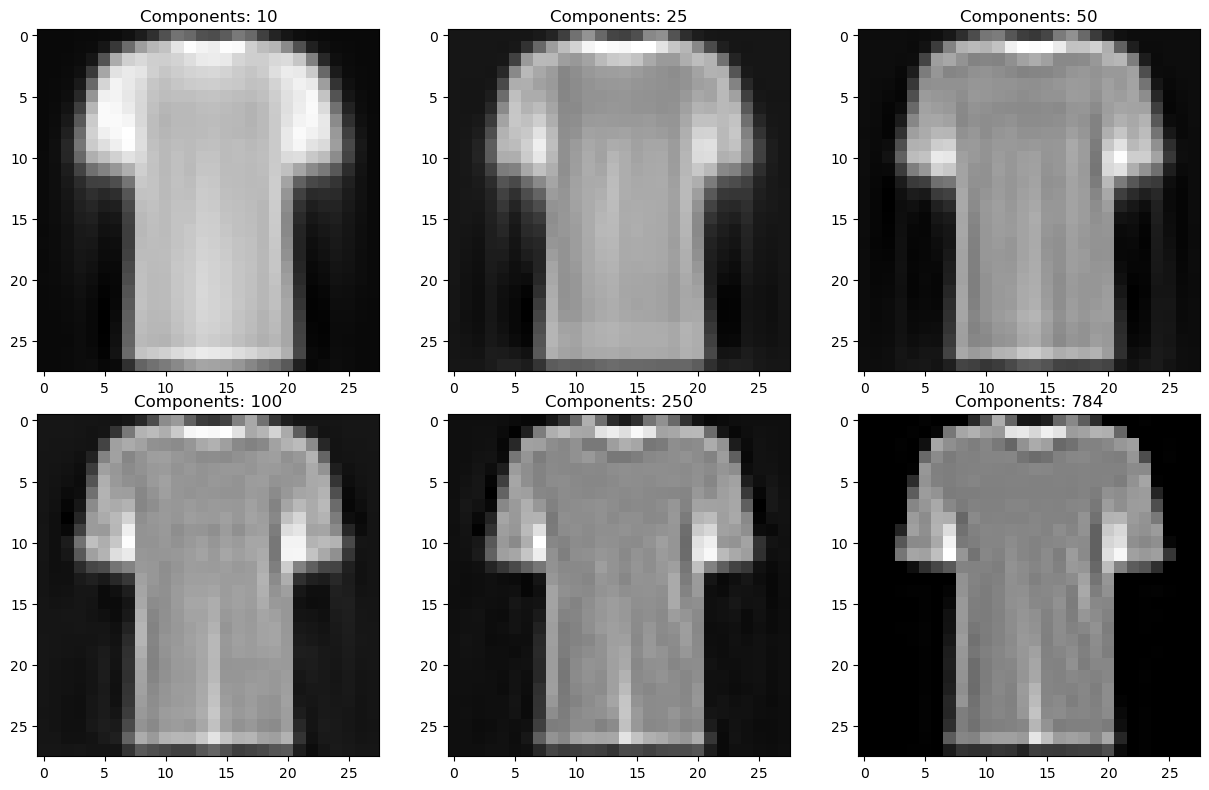

In [55]:
def plot_at_k(k):
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[0].reshape(28,28)
    plt.imshow(image_recon,cmap = plt.cm.gray)

ks = [10, 25, 50, 100, 250, 784]
plt.figure(figsize=[15,10])

for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]))

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

We chose to use 100 components. The reason behind this is that we want to have a relativly low number of features but also to retain high variance. In 100 components we retain 89.01% of the original information. So we concider this as a good combination.

In [38]:
#We save our PCA for external analysis and 
 # Transforms data to 50 components
X_scaled_train = scaler.fit_transform(train_data_X)
pca_100dim = PCA(n_components=100)
X_reduced_100=pca_100dim.fit_transform(X_scaled_train)
# Step 2: Pickle the fitted PCA model
X_scaled_test = scaler.fit_transform(test_data_X)
test_X_reduced_100=pca_100dim.transform(X_scaled_test)
#print(test_X_reduced_100.shape)

# Classification models

## 1.Manual implementations
### 1.1 Decicion tree

Our implementation:

In [39]:

class TreeNode:
    def __init__(self, data, feature_idx, feature_val, prediction_probs):
        self.data = data
        self.feature_idx = feature_idx
        self.feature_val = feature_val
        self.prediction_probs = prediction_probs
        self.left = None
        self.right = None

    def node_def(self):
        unique_values, value_counts = np.unique(self.data[:, -1], return_counts=True)
        output = ", ".join([f"{value}->{count}" for value, count in zip(unique_values, value_counts)])
        return f"LEAF | Label Counts = {output} | Pred Probs = {self.prediction_probs}"

class DecisionTreeFromScratch:
    def __init__(self, max_depth, min_leaf):
        self.max_depth = max_depth
        self.min_leaf = min_leaf
        self.tree = None

    def _entropy(self, class_probabilities):
        return sum([-p * np.log2(p) for p in class_probabilities if p > 0])

    def _class_probabilities(self, labels):
        total_count = len(labels)
        return [count / total_count for count in Counter(labels).values()]

    def _data_entropy(self, labels):
        return self._entropy(self._class_probabilities(labels))

    def _partition_entropy(self, subsets):
        total_count = sum(len(subset) for subset in subsets)
        return sum(self._data_entropy(subset) * (len(subset) / total_count) for subset in subsets)

    def _split_indices(self, data, feature_index, feature_val):
        mask = data[:, feature_index] < feature_val
        return np.where(mask)[0], np.where(~mask)[0]

    def _find_best_split(self, data):
        min_part_entropy = float('inf')
        best_split = None
        n_features = data.shape[1] - 1  # Exclude label column

        for idx in range(n_features):
            feature_vals = np.percentile(data[:, idx], q=np.linspace(0, 100, num=20))  # Optimize thresholds
            for feature_val in feature_vals:
                left_idx, right_idx = self._split_indices(data, idx, feature_val)
                if len(left_idx) == 0 or len(right_idx) == 0:  # Skip invalid splits
                    continue
                part_entropy = self._partition_entropy([data[left_idx, -1], data[right_idx, -1]])
                if part_entropy < min_part_entropy:
                    min_part_entropy = part_entropy
                    best_split = (left_idx, right_idx, idx, feature_val, min_part_entropy)

        return best_split if best_split else (None, None, None, None, None)

    def _find_label_probs(self, labels):
        total_labels = len(labels)
        label_probabilities = np.zeros(len(self.labels_in_train), dtype=float)
        for i, label in enumerate(self.labels_in_train):
            count = np.sum(labels == label)
            label_probabilities[i] = count / total_labels
        return label_probabilities

    def _create_tree(self, data, indices, current_depth):
        if current_depth >= self.max_depth or len(indices) < self.min_leaf:
            return None

        split = self._find_best_split(data[indices])
        if not split:
            return None

        left_idx, right_idx, split_feature_idx, split_feature_val, _ = split
        left_data_indices = indices[left_idx]
        right_data_indices = indices[right_idx]
        label_probabilities = self._find_label_probs(data[indices, -1])

        node = TreeNode(data[indices], split_feature_idx, split_feature_val, label_probabilities)
        if len(left_data_indices) < self.min_leaf or len(right_data_indices) < self.min_leaf:
            return node

        current_depth += 1
        node.left = self._create_tree(data, left_data_indices, current_depth)
        node.right = self._create_tree(data, right_data_indices, current_depth)
        return node

    def _predict_one_sample(self, X):
        node = self.tree
        while node.left or node.right:
            if X[node.feature_idx] < node.feature_val:
                node = node.left
            else:
                node = node.right
        return node.prediction_probs

    def fit(self, X_train, Y_train):
        self.labels_in_train = np.unique(Y_train)
        train_data = np.concatenate((X_train, np.reshape(Y_train, (-1, 1))), axis=1)
        indices = np.arange(len(train_data))
        self.tree = self._create_tree(data=train_data, indices=indices, current_depth=0)

    def predict_proba(self, X_set):
        return np.apply_along_axis(self._predict_one_sample, 1, X_set)

    def predict(self, X_set):
        pred_probs = self.predict_proba(X_set)
        return np.argmax(pred_probs, axis=1)

    def evaluate_model(self, X_val, y_val, labels):
        predictions = self.predict(X_val)
        accuracy = accuracy_score(y_val, predictions)
        recall_per_class = recall_score(y_val, predictions, average=None, labels=labels)
        conf_matrix = confusion_matrix(y_val, predictions, labels=labels)

        print("Overall Accuracy:", accuracy)
        print("Recall per Class:")
        for label, recall in zip(labels, recall_per_class):
            print(f"Class {label}: {recall:.4f}")
        print("\nConfusion Matrix:\n", conf_matrix)

        return accuracy, recall_per_class, conf_matrix

# Main Code: Data Loading and Cross-Validation


In [40]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_recalls = []
fold_conf_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(X_reduced_100)):
    print(f"\nTraining Fold {fold + 1}")

    X_train, X_val = X_reduced_100[train_index], X_reduced_100[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]

    house_plant = DecisionTreeFromScratch(max_depth=10, min_leaf=10)
    house_plant.fit(X_train, y_train)
    labels = np.unique(y_train)

    accuracy, recall_per_class, conf_matrix = house_plant.evaluate_model(X_val, y_val, labels)
    fold_accuracies.append(accuracy)
    fold_recalls.append(recall_per_class)
    fold_conf_matrices.append(conf_matrix)
    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

# Print Final Results
print("\nFinal Cross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print("Mean Recall per Class:", np.mean(fold_recalls, axis=0))

# Print Final Results
print("\nFinal Cross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.2f}")
print("Mean Recall per Class:", np.mean(fold_recalls, axis=0))


Training Fold 1
Overall Accuracy: 0.7755
Recall per Class:
Class 0: 0.7807
Class 1: 0.9472
Class 2: 0.7552
Class 3: 0.8543
Class 4: 0.5545

Confusion Matrix:
 [[324  10   9  16  56]
 [  3 359   1  14   2]
 [ 10   9 293   6  70]
 [ 24  10   8 346  17]
 [ 80   8  65  31 229]]
Fold 1 Accuracy: 0.7755

Training Fold 2
Overall Accuracy: 0.758
Recall per Class:
Class 0: 0.7613
Class 1: 0.9313
Class 2: 0.7624
Class 3: 0.8308
Class 4: 0.5000

Confusion Matrix:
 [[303   7   9  31  48]
 [  4 366   5  15   3]
 [ 15   2 324  17  67]
 [ 22  19   7 329  19]
 [ 88  10  70  26 194]]
Fold 2 Accuracy: 0.7580

Training Fold 3
Overall Accuracy: 0.7765
Recall per Class:
Class 0: 0.7945
Class 1: 0.9296
Class 2: 0.8033
Class 3: 0.8442
Class 4: 0.5376

Confusion Matrix:
 [[317   4   5  20  53]
 [  6 370   1  15   6]
 [  3   4 294   8  57]
 [ 32  11   8 336  11]
 [ 95   7  71  30 236]]
Fold 3 Accuracy: 0.7765

Training Fold 4
Overall Accuracy: 0.784
Recall per Class:
Class 0: 0.7494
Class 1: 0.8816
Class 2: 0

### 1.2 Feed-forward neural network

Our implementation:

In [295]:
#define neural network layer
def one_hot_encode(Y, num_classes):
    return np.eye(num_classes)[Y]
class Layer():
    def __init__(self, n_num, input_dim):
        self.weights = self.initialize_parameters(n_num, input_dim)
        self.gamma = np.ones((n_num, 1))  # Scaling factor
        self.beta = np.zeros((n_num, 1)) 

    def initialize_parameters(self, n_num, input_dim):
        """Initialize parameters with He initialization method"""
        
        parameters = {}
        parameters["W"] = np.random.randn(n_num, input_dim) * np.sqrt(2/input_dim)
        parameters["b"] = np.zeros((n_num, 1))

        return parameters
    
class Adam_optimizer():
    def __init__(self, learning_rate, beta1, beta2, epsilon):
        self.momentum_w = {}
        self.momentum_b = {}
        self.rms_w = {}
        self.rms_b = {}
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.learning_rate = learning_rate
        self.t = 0  # Time step for bias correction


    def update_parameters(self, parameters, gradients):#(self, t, l_num, b, dw, db):
        ## Compute decayed learning rate
        
        ## dw, db are from current minibatch
        ## momentum beta 1
        # *** weights *** #
        self.t += 1
        
        # Update parameters for each layer
        for l_num, l in enumerate(parameters, start=1):
            #print(l_num)
            #print(gradients["dW" + str(l_num)].shape, )
            # Initialize caches if not already present
            if l_num not in self.momentum_w:
                self.momentum_w[l_num] = np.zeros_like(parameters[l_num-1][0].weights['W'])
                self.momentum_b[l_num] = np.zeros_like(parameters[l_num-1][0].weights['b'])
                self.rms_w[l_num] = np.zeros_like(parameters[l_num-1][0].weights['W'])
                self.rms_b[l_num] = np.zeros_like(parameters[l_num-1][0].weights['b'])
            # Momentum updates
            self.momentum_w[l_num] = self.beta1 * self.momentum_w[l_num] + (1 - self.beta1) * gradients["dW" + str(l_num)]
            self.momentum_b[l_num] = self.beta1 * self.momentum_b[l_num] + (1 - self.beta1) * gradients["db" + str(l_num)]
            
            # RMS updates
            self.rms_w[l_num] = self.beta2 * self.rms_w[l_num] + (1 - self.beta2) * (gradients["dW" + str(l_num)]**2)
            self.rms_b[l_num] = self.beta2 * self.rms_b[l_num] + (1 - self.beta2) * (gradients["db" + str(l_num)]**2)
            
            # Bias correction
            momentum_w_corr = self.momentum_w[l_num] / (1 - self.beta1**self.t)
            momentum_b_corr = self.momentum_b[l_num] / (1 - self.beta1**self.t)
            rms_w_corr = self.rms_w[l_num] / (1 - self.beta2**self.t)
            rms_b_corr = self.rms_b[l_num] / (1 - self.beta2**self.t)

            # Update weights and biases
            l[0].weights['W'] -= self.learning_rate* (momentum_w_corr / (np.sqrt(rms_w_corr) + self.epsilon))
            l[0].weights['b'] -= self.learning_rate * (momentum_b_corr / (np.sqrt(rms_b_corr) + self.epsilon))
            
        return parameters

class Mini_Batch_GD_optimizer():
    def __init__(self, learning_rate, decay_rate=0.01):
        #gradients=self.find_gradients(parameters, forward_vars, Y)
        #self.update_parameters(parameters, gradients, learning_rate)
        self.learning_rate=learning_rate
        self.decay_rate=decay_rate
    
    def update_parameters(self, parameters, gradients, epoch):
        decayed_learning_rate = self.learning_rate * np.exp(-self.decay_rate * epoch)
        l_num=0
        for l in parameters:
            l[0].weights['W'] -= decayed_learning_rate * gradients["dW"+str(l_num)]
            l[0].weights['b'] -= decayed_learning_rate * gradients["db"+str(l_num)]
            l_num+=1
        return parameters
    
#define fnn    
class FFNN():
    def __init__(self):
        self.layers=[]
        self.optimizer=None
        self.metrics={}
        self.early_stopping = None
    
    def add_layer(self, n_num, input_dim=None, activation="relu"):
        if input_dim is None:
            if len(self.layers) == 0:
                raise ValueError("Input dimension must be provided for the first layer.")
            input_dim = len(self.layers[-1][0].weights['W'])
        new_layer = Layer(n_num, input_dim)
        self.layers.append([new_layer, activation])
    
    def compile(self, optimizer='adam', learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, metrics=['accuracy'], early_stopping=None):
        if optimizer=='adam':
            self.optimizer=Adam_optimizer(learning_rate, beta1, beta2, epsilon )
        elif optimizer=='mini':
            self.optimizer=Mini_Batch_GD_optimizer(learning_rate)
        for m in metrics: self.metrics.update({m : []})
        self.early_stopping = early_stopping
        
    def fit(self, X_train, Y_train, X_val, Y_val, batch_size, epochs=0):
        self.minibatch_size = batch_size
        temp_weights=self.layers.copy()
        best_weights = None
        best_epoch = 0
        best_val_loss = float('inf')
        patience_counter = 0

        for i in range(epochs):
            for batch_idx in range(0, int(X_train.shape[0] / batch_size)):
                # Mini Batch Samples
                if batch_idx == int(X_train.shape[1] / batch_size):
                    X = X_train[:, batch_idx*batch_size:]
                    Y = Y_train[:, batch_idx*batch_size:]
                else:
                    X = X_train[:, batch_idx*batch_size: (batch_idx+1)*batch_size]
                    Y = Y_train[:, batch_idx*batch_size: (batch_idx+1)*batch_size]

                output_history = self.feed_forward(temp_weights, X)
                gradients = self.backward_prop(temp_weights, output_history, Y)
                temp_weights = self.optimizer.update_parameters(temp_weights, gradients)
            
            history=self.feed_forward(temp_weights, X_train)
            predictions = history["A"+str(len(self.layers))]
            y_pred =np.argmax(predictions, axis=0) 
            self.get_stats(one_hot_encode(y_pred, 5), Y_train.T)

            # Validation loss
            val_history = self.feed_forward(temp_weights, X_val)
            val_predictions = val_history["A"+str(len(self.layers))]
            self.metrics['val_accuracy'].append(accuracy_score(Y_val.T, one_hot_encode(np.argmax(val_predictions, axis=0),5)))
            val_predictions = np.clip(val_predictions, 1e-10, 1.0) 
            val_loss = -np.sum(Y_val * np.log(val_predictions + 10**-100))/int(Y_val.shape[1])
            
            #print(val_loss)
            self.metrics['val_loss'].append(val_loss)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights = temp_weights.copy()
                best_epoch = i
                patience_counter = 0
            else:
                patience_counter += 1

            if self.early_stopping and patience_counter >= self.early_stopping['patience']:
                print(f"Early stopping at epoch {i+1}")
                break

        self.layers = best_weights
        print(f"Best epoch: {best_epoch+1}, Best validation loss: {best_val_loss}")

    def feed_forward(self, temp_weights, I):
        forward_vars = {"A0": I}
        running_mean, running_var = {}, {}
        
        for l_num in range(1, len(temp_weights) + 1):
            layer = temp_weights[l_num - 1]
            forward_vars["Z"+str(l_num)] = np.dot(layer[0].weights['W'], forward_vars["A" + str(l_num - 1)]) + layer[0].weights['b']

            # Batch Normalization
            mean = np.mean(forward_vars["Z"+str(l_num)], axis=1, keepdims=True)
            var = np.var(forward_vars["Z"+str(l_num)], axis=1, keepdims=True)
            Z_norm = (forward_vars["Z"+str(l_num)] - mean) / np.sqrt(var + 1e-8)
            Z_bn = layer[0].gamma * Z_norm + layer[0].beta

            # Save running mean and variance for inference
            running_mean[l_num] = mean
            running_var[l_num] = var

            # Activation
            forward_vars["Z" + str(l_num)] = Z_bn
            forward_vars["A" + str(l_num)] = self._activate(Z_bn, layer[1])
        return forward_vars
    
    def backward_prop(self, parameters, forward_vars, Y):
        gradients = {}
        l_num = len(parameters)

        for l_num in range(len(parameters), 0, -1):
            m = forward_vars["A" + str(l_num - 1)].shape[1]
            layer = parameters[l_num - 1]

            if layer[1] == 'sigmoid':
                gradients["dA" + str(l_num)] = -np.divide(Y, forward_vars["A" + str(l_num)]) + np.divide((1 - Y), (1 - forward_vars["A" + str(l_num)]))
                gradients["dZ" + str(l_num)] = gradients["dA" + str(l_num)] * forward_vars["A" + str(l_num)] * (1 - forward_vars["A" + str(l_num)])
            elif layer[1] == 'relu':
                relu_derivative = forward_vars["A"+str(l_num)] > 0
                gradients["dZ"+str(l_num)] = np.multiply(gradients["dA"+str(l_num)], relu_derivative)
            elif layer[1] == "leaky_relu":
                leaky_relu_derivative = np.where(forward_vars["A" + str(l_num)] > 0, 1, 0.01)
                gradients["dZ" + str(l_num)] = np.multiply(gradients["dA" + str(l_num)], leaky_relu_derivative)
            elif layer[1] == 'softmax':
                gradients["dZ"+str(l_num)] = forward_vars["A"+str(l_num)] - Y 
            
            dZ = gradients["dZ" + str(l_num)]
            mean = np.mean(forward_vars["Z" + str(l_num)], axis=1, keepdims=True)
            var = np.var(forward_vars["Z" + str(l_num)], axis=1, keepdims=True)
            Z_norm = (forward_vars["Z" + str(l_num)] - mean) / np.sqrt(var + 1e-8)

            gradients["dgamma" + str(l_num)] = np.sum(dZ * Z_norm, axis=1, keepdims=True)
            gradients["dbeta" + str(l_num)] = np.sum(dZ, axis=1, keepdims=True)
            dZ_norm = dZ * layer[0].gamma

            dvar = np.sum(dZ_norm * (forward_vars["Z" + str(l_num)] - mean) * -0.5 * (var + 1e-8) ** (-1.5), axis=1, keepdims=True)
            dmean = np.sum(dZ_norm * -1 / np.sqrt(var + 1e-8), axis=1, keepdims=True) + dvar * np.mean(-2 * (forward_vars["Z" + str(l_num)] - mean), axis=1, keepdims=True)
            gradients["dZ" + str(l_num)] = dZ_norm / np.sqrt(var + 1e-8) + dvar * 2 * (forward_vars["Z" + str(l_num)] - mean) / m + dmean / m

            gradients["dW" + str(l_num)] = (1 / m) * np.dot(gradients["dZ" + str(l_num)], forward_vars["A" + str(l_num - 1)].T)
            gradients["db" + str(l_num)] = (1 / m) * np.sum(gradients["dZ" + str(l_num)], axis=1, keepdims=True)
            gradients["dA" + str(l_num - 1)] = np.dot(layer[0].weights['W'].T, gradients["dZ" + str(l_num)])
        return gradients
    
    def predict(self, X):
        forward_vars = self.feed_forward(self.layers, X)
        L = len(self.layers)
        return forward_vars["A"+str(L)]
    
    def _activate(self, I, activation):
        if activation=='relu':
            result=np.maximum(0, I)
        elif activation == 'leaky_relu':
            result = np.where(I > 0, I, 0* I) 
        elif activation=='softmax':
            T = np.exp(I - np.max(I, axis=0, keepdims=True))
            T_sum = np.sum(T, axis=0, keepdims=True)
            result = np.divide(T, T_sum)
        elif activation=='sigmoid':
            result = 1 / (1 + np.exp(-I))
        else:
            print("Error")
        return result
    
    def get_stats(self, Y_hat, Y, num_classes=5):
        if 'loss' in self.metrics.keys():
            self.metrics['loss'].append(-np.sum(Y * np.log(Y_hat + 10**-100))/int(Y_hat.shape[0]))
            #print(Y_hat.shape[0])
        if 'accuracy' in self.metrics.keys():
            accuracy = accuracy_score(Y, Y_hat)
            self.metrics['accuracy'].append(accuracy)
        if 'micro_recall' in self.metrics.keys():
            micro_recall = recall_score(Y, Y_hat, average='micro')
            self.metrics['micro_recall'].append(micro_recall)
        if 'macro_recall' in self.metrics.keys():
            macro_recall = recall_score(Y, Y_hat, average='macro')
            self.metrics['macro_recall'].append(macro_recall)
        if 'weighted_recall' in self.metrics.keys():
            weighted_recall = recall_score(Y, Y_hat, average='weighted')
            self.metrics['weighted_recall'].append(weighted_recall)
        return



In [296]:
def create_multiclass_model_from_scratch_raw(input_dim, num_classes):
    model_fnn_s = FFNN()
    model_fnn_s.add_layer(256, input_dim=input_dim, activation='leaky_relu') # First hidden layer
    model_fnn_s.add_layer(128, activation='leaky_relu') # First hidden layer
    model_fnn_s.add_layer(64, activation='leaky_relu')  # Second hidden layer
    model_fnn_s.add_layer(32, activation='leaky_relu')  # Third hidden layer
    model_fnn_s.add_layer(num_classes, activation='softmax')  # Output layer for multi-class classification
  
    # Compile the model
    model_fnn_s.compile(optimizer='adam',learning_rate=0.001,
                 #loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                 metrics=['accuracy', 'loss','val_accuracy', 'val_loss'], 
                 early_stopping={'patience': 10}
                 )
    return model_fnn_s
def create_multiclass_model_from_scratch_pca(input_dim, num_classes):
    model_fnn_s_100 = FFNN()
    model_fnn_s_100.add_layer(128, input_dim=input_dim, activation='leaky_relu') # First hidden layer
    model_fnn_s_100.add_layer(64, activation='leaky_relu')  # Second hidden layer
    model_fnn_s_100.add_layer(32, activation='leaky_relu')  # Third hidden layer
    model_fnn_s_100.add_layer(num_classes, activation='softmax')  # Output layer for multi-class classification
  
    # Compile the model
    model_fnn_s_100.compile(optimizer='adam',learning_rate=0.001,
                 #loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                 metrics=['accuracy', 'loss','val_accuracy', 'val_loss'],
                 early_stopping={'patience': 10}
    )
   
    return model_fnn_s_100

5-fold cross-validation with raw data

In [297]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index].T, train_data_X[val_index].T
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    y_train = one_hot_encode(y_train, 5).T
    
    # Create a new instance of the model
    model_fnn_s = create_multiclass_model_from_scratch_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
    
    # Train the model
    model_fnn_s.fit(X_train, y_train, X_val, one_hot_encode(y_val, 5).T , epochs=100, batch_size=32)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model_fnn_s.predict(X_val), axis=0)  # Get the predicted class for each sample
    
    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

Training fold 1
Early stopping at epoch 38
Best epoch: 28, Best validation loss: 0.665257838114211
Fold 1 Accuracy: 0.8160
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79       415
           1       0.99      0.96      0.97       379
           2       0.77      0.84      0.80       388
           3       0.91      0.88      0.89       405
           4       0.64      0.63      0.64       413

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

Confusion Matrix for Fold 1:
 [[329   1  12  11  62]
 [  3 362   5   7   2]
 [  2   0 324   5  57]
 [ 11   4  11 355  24]
 [ 69   0  70  12 262]]
Training fold 2
Early stopping at epoch 35
Best epoch: 25, Best validation loss: 0.669580302164639
Fold 2 Accuracy: 0.8085
Classification Report for Fold 2:
               precision    recall  f1-score   sup

[0.7490581553495306, 0.66973707541458, 0.6483626942823439, 0.6553712517317328, 0.6896415323819568, 0.7198630333018403, 0.6892703904042926, 0.6754239569211634, 0.663716883733434, 0.6704703298661914, 0.6745569935990628, 0.6444694371093619, 0.6649347444610412, 0.6599420304560517, 0.6411401099668276, 0.6642243928306488, 0.6428547132099443, 0.6395274840558376, 0.633458131311794, 0.6304745217028949, 0.6325994276259037, 0.6326766256199735, 0.6334360923587776, 0.6281251936452313, 0.6349224419877741, 0.6345039456690889, 0.6252327334676007, 0.6307763132618495, 0.650421309313414, 0.6656740276573289, 0.6443121234914013, 0.6302273814376759, 0.6422091737434628, 0.6458426078759765, 0.6375255194068321, 0.6317596056073549, 0.6382335917029592]
[49.64949106768411, 41.907048692491635, 39.11516426723636, 40.093762931758825, 43.40372900293776, 45.61996715494453, 43.14468817997593, 41.475313987555246, 40.75575614599461, 41.158708537268566, 42.07974257446619, 38.510735680325425, 39.80593979513458, 39.83472210

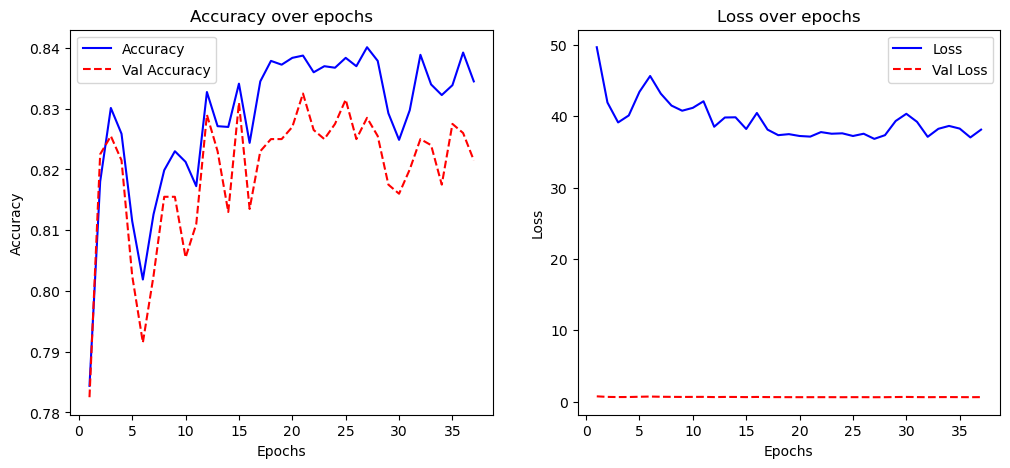

In [298]:
# fix plots with val stats and loss numbers
def plot_metrics(metrics):
    epochs = range(1, len(metrics['loss']) + 1)
    
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, metrics['loss'], 'b-', label='Loss')
    if 'val_loss' in metrics:
        plt.plot(epochs, metrics['val_loss'], 'r--', label='Val Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, metrics['accuracy'], 'b-', label='Accuracy')
    if 'val_accuracy' in metrics:
        plt.plot(epochs, metrics['val_accuracy'], 'r--', label='Val Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# Example usage after cross-validation
print(model_fnn_s.metrics['val_loss'])
print(model_fnn_s.metrics['loss'])
plot_metrics(model_fnn_s.metrics)


5-fold cross-validation with 100 components

In [299]:
kf = KFold(n_splits=5, shuffle=True)
fold_accuracies_pca = []
all_classification_reports_pca = []
all_confusion_matrices_pca = []
def one_hot_encode(Y, num_classes):
    return np.eye(num_classes)[Y]
    # Split the data into training and validation sets for the current fold
    
for fold, (train_index, val_index) in enumerate(kf.split(X_reduced_100)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = X_reduced_100[train_index].T, X_reduced_100[val_index].T
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    y_train = one_hot_encode(y_train, 5).T
    # Create a new instance of the model
    model_fnn_s_100 = create_multiclass_model_from_scratch_pca(input_dim=X_reduced_100.shape[1], num_classes=len(np.unique(train_data_y)))
    #print(X_val.shape, X_train.shape)
    
    # Train the model
    #model.fit(X_train, y_train, epochs=100, batch_size=32)
    model_fnn_s_100.fit(X_train, y_train, X_val, one_hot_encode(y_val, 5).T, epochs=100, batch_size=32)

    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model_fnn_s_100.predict(X_val), axis=0)  # Get the predicted class for each sample
    #print(y_val_pred.shape)
    #print(y_val.shape)
    # Calculate accuracy for the current fold
    accuracy_pca = accuracy_score(y_val, y_val_pred)
    fold_accuracies_pca.append(accuracy_pca)
    
    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports_pca.append(class_report)
    all_confusion_matrices_pca.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy_pca:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy_pca = np.mean(fold_accuracies_pca)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy_pca:.4f}")

Training fold 1
Early stopping at epoch 26
Best epoch: 16, Best validation loss: 0.9896070795993526
Fold 1 Accuracy: 0.6855
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.70      0.67      0.68       435
           1       0.86      0.88      0.87       404
           2       0.59      0.59      0.59       386
           3       0.72      0.81      0.76       396
           4       0.52      0.47      0.50       379

    accuracy                           0.69      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.68      0.69      0.68      2000

Confusion Matrix for Fold 1:
 [[290  14  47  44  40]
 [  5 355  10  30   4]
 [ 24  17 227  12 106]
 [ 32  10  21 319  14]
 [ 63  16  82  38 180]]
Training fold 2
Early stopping at epoch 26
Best epoch: 16, Best validation loss: 1.1907513148451476
Fold 2 Accuracy: 0.5905
Classification Report for Fold 2:
               precision    recall  f1-score   s

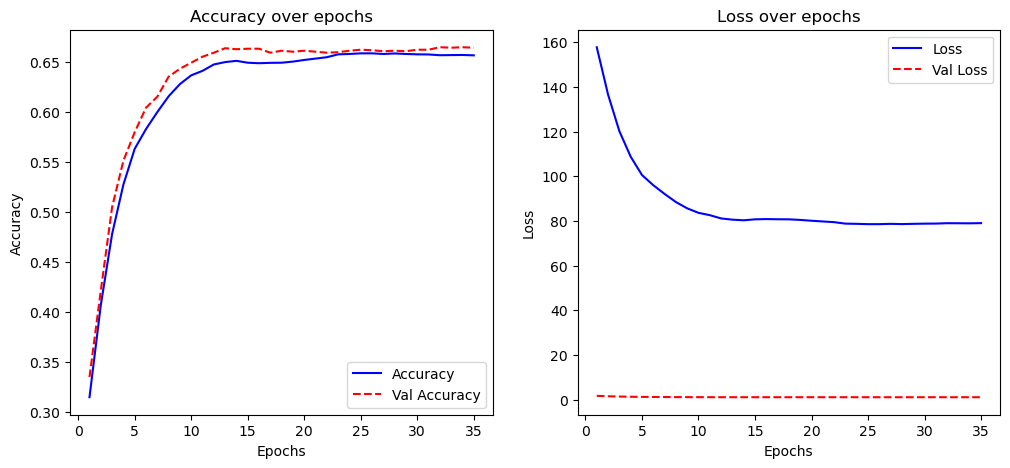

In [300]:
plot_metrics(model_fnn_s_100.metrics)

## 2. Reference  implementations
### 2.1 Decicion tree

Grid search with raw data

In [61]:
#Grid search for best parameters
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [ 10, 15, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize the Decision Tree model
dt = tree.DecisionTreeClassifier()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(train_data_X, train_data_y)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy score:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validated accuracy score: 0.8022


Grid search with 100 components data

In [63]:
#Grid search for best parameters
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': [None]
}

# Initialize the Decision Tree model
dt = tree.DecisionTreeClassifier()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_reduced_100, train_data_y)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy score:", grid_search.best_score_)

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validated accuracy score: 0.7631


## 2.2 Feed-forward neural network

Model building

In [237]:
def create_multiclass_model_raw(input_dim, num_classes):
    model_fnn_tf = Sequential()
    model_fnn_tf.add(Dense(256, input_dim=input_dim, activation='leaky_relu'))
    model_fnn_tf.add(BatchNormalization())
    model_fnn_tf.add(Dense(128, activation='leaky_relu'))  # First hidden layer
    model_fnn_tf.add(BatchNormalization())
    model_fnn_tf.add(Dense(64, activation='leaky_relu'))  # Second hidden layer
    model_fnn_tf.add(BatchNormalization())
    model_fnn_tf.add(Dense(32, activation='leaky_relu'))  # Third hidden layer
    model_fnn_tf.add(Dense(num_classes, activation='softmax'))  # Output layer for multi-class classification
    
    # Compile the model
    model_fnn_tf.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                  metrics=['accuracy'])
    return model_fnn_tf

def create_multiclass_model_pca(input_dim, num_classes):
    model_fnn_tf_100 = Sequential()
    model_fnn_tf_100.add(Dense(128, input_dim=input_dim, activation='leaky_relu'))  # First hidden layer
    model_fnn_tf_100.add(BatchNormalization())
    model_fnn_tf_100.add(Dense(64, activation='leaky_relu'))  # Second hidden layer
    model_fnn_tf_100.add(BatchNormalization())
    model_fnn_tf_100.add(Dense(32, activation='leaky_relu'))  # Third hidden layer
    model_fnn_tf_100.add(Dense(num_classes, activation='softmax'))  # Output layer for multi-class classification
    
    # Compile the model
    model_fnn_tf_100.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                  metrics=['accuracy'])
    return model_fnn_tf_100

In [301]:
def plot_training_history(history):
    # Extract accuracy and loss values for both training and validation
    accuracy = history.history['accuracy']
    val_accuracy = history.history.get('val_accuracy', [])
    loss = history.history['loss']
    val_loss = history.history.get('val_loss', [])

    epochs = range(1, len(accuracy) + 1)

    # Plot Accuracy
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
    if val_accuracy:
        plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Show the plots
    plt.tight_layout()
    plt.show()

5-fold cross-validation with raw data

In [303]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index], train_data_X[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the model
    model = create_multiclass_model_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
    
    # Define EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=15,         # Stop if no improvement after 10 epochs
        restore_best_weights=True  # Restore weights from the best epoch
    )
    
    # Train the model with validation and early stopping
    history_fnn_tf = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping]
    )
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")


Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 1 Accuracy: 0.8465
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.73      0.93      0.82       415
           1       0.99      0.96      0.98       379
           2       0.88      0.82      0.85       388
           3       0.92      0.86      0.89       405
           4       0.75      0.66      0.70       413

    accuracy                           0.85      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion Matrix for Fold 1:
 [[386   1   5   6  17]
 [  4 365   2   3   5]
 [  8   0 320   6  54]
 [ 36   0   5 350  14]
 [ 92   1  31  17 272]]
Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 2 Accuracy: 0.8415
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79       398
           1       1.00      0.96      0.98       393
           2       0.86      0.88      0.87       425
           3       0.84      0.90      0.87       396
           4       0.70      0.69      0.70       388

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

Confusion Matrix for Fold 2:
 [[307   0  10  34  47]
 [  3 379   2   8   1]
 [  4   0 372   6  43]
 [ 15   0   2 358  21]
 [ 54   1  46  20 267]]
Training fold 3


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 3 Accuracy: 0.8460
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.76      0.85      0.80       399
           1       0.99      0.97      0.98       398
           2       0.81      0.89      0.85       366
           3       0.86      0.94      0.90       398
           4       0.82      0.61      0.70       439

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.84      2000

Confusion Matrix for Fold 3:
 [[340   0   9  20  30]
 [  1 385   2   9   1]
 [  6   0 325  14  21]
 [ 11   2   3 375   7]
 [ 88   0  64  20 267]]
Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 4 Accuracy: 0.8700
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.86      0.80      0.83       411
           1       0.98      0.97      0.97       414
           2       0.87      0.91      0.89       406
           3       0.84      0.94      0.89       396
           4       0.78      0.72      0.75       373

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 4:
 [[330   0   7  34  40]
 [  1 400   0  12   1]
 [  4   0 369   6  27]
 [  7   6   4 373   6]
 [ 40   1  46  18 268]]
Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 5 Accuracy: 0.8630
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.80      0.90      0.85       410
           1       1.00      0.96      0.98       363
           2       0.83      0.89      0.86       416
           3       0.91      0.90      0.91       410
           4       0.79      0.67      0.73       401

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion Matrix for Fold 5:
 [[368   0   6   4  32]
 [  4 348   1  10   0]
 [  9   1 370   5  31]
 [ 18   0  12 371   9]
 [ 59   0  57  16 269]]

Average Accuracy across 5 folds: 0.8534


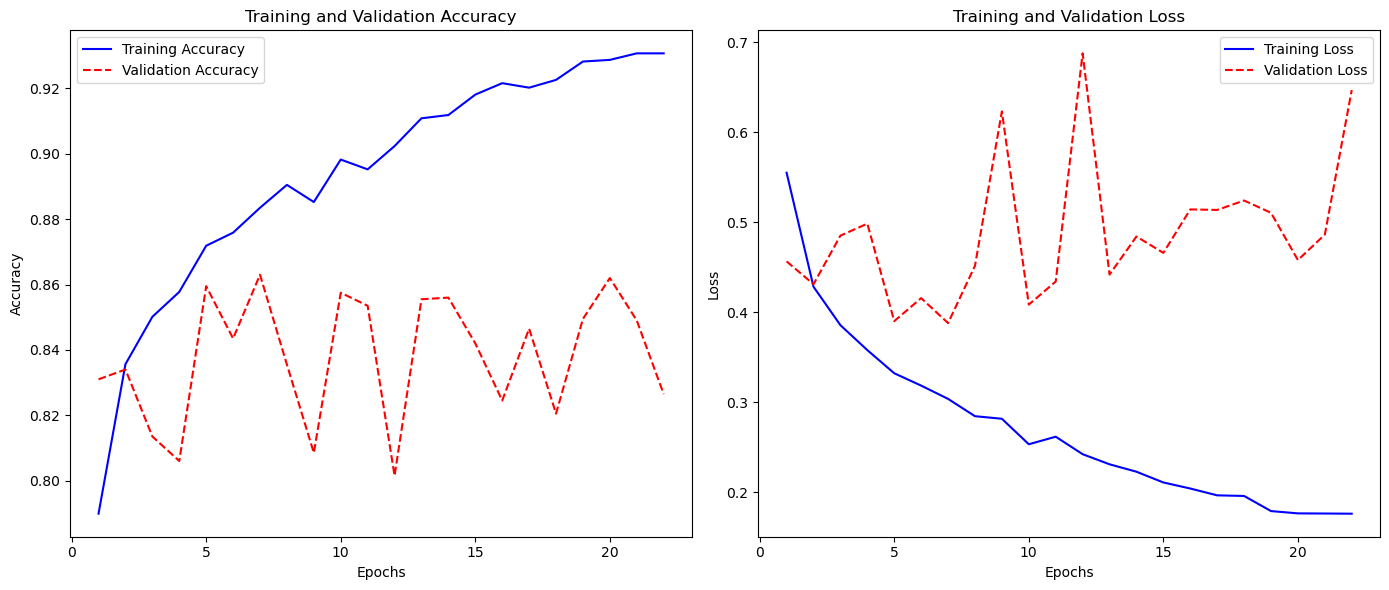

In [304]:
plot_training_history(history_fnn_tf)

5-fold cross-validation with 100 components

In [308]:
# pca
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(X_reduced_100)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = X_reduced_100[train_index], X_reduced_100[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the model
    model = create_multiclass_model_pca(input_dim=X_reduced_100.shape[1], num_classes=len(np.unique(train_data_y)))
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=15,         # Stop if no improvement after 10 epochs
        restore_best_weights=True  # Restore weights from the best epoch
    )
    
    # Train the model with validation and early stopping
    history_fnn_tf_100 = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping]
    )
    
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    accuracy_pca = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy_pca)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy_pca:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy_pca = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy_pca:.4f}")

Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 1 Accuracy: 0.8635
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84       415
           1       0.99      0.97      0.98       379
           2       0.83      0.86      0.85       388
           3       0.90      0.92      0.91       405
           4       0.76      0.74      0.75       413

    accuracy                           0.86      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.86      0.86      0.86      2000

Confusion Matrix for Fold 1:
 [[349   0   8  14  44]
 [  2 368   3   5   1]
 [  8   1 334   5  40]
 [ 13   0  11 372   9]
 [ 45   1  46  17 304]]
Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 2 Accuracy: 0.8425
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.78      0.82      0.80       398
           1       0.98      0.98      0.98       393
           2       0.85      0.87      0.86       425
           3       0.86      0.91      0.89       396
           4       0.73      0.64      0.68       388

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

Confusion Matrix for Fold 2:
 [[325   0   7  23  43]
 [  2 385   2   3   1]
 [  8   0 368  11  38]
 [ 15   6   4 360  11]
 [ 65   2  54  20 247]]
Training fold 3


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 3 Accuracy: 0.8485
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80       399
           1       0.99      0.97      0.98       398
           2       0.83      0.86      0.85       366
           3       0.87      0.91      0.89       398
           4       0.78      0.69      0.73       439

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion Matrix for Fold 3:
 [[330   0   7  19  43]
 [  3 385   2   8   0]
 [  6   0 316   7  37]
 [ 18   5   4 364   7]
 [ 65   0  52  20 302]]
Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 4 Accuracy: 0.8785
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.84      0.85      0.85       411
           1       0.98      0.98      0.98       414
           2       0.90      0.86      0.88       406
           3       0.91      0.94      0.93       396
           4       0.75      0.75      0.75       373

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix for Fold 4:
 [[350   2   6  11  42]
 [  0 404   0   9   1]
 [  8   1 350   4  43]
 [  9   5   2 373   7]
 [ 50   2  30  11 280]]
Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 5 Accuracy: 0.8670
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.85      0.80      0.83       410
           1       0.98      0.96      0.97       363
           2       0.89      0.88      0.89       416
           3       0.88      0.94      0.91       410
           4       0.74      0.76      0.75       401

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 5:
 [[330   1   5  15  59]
 [  2 348   0  12   1]
 [  7   2 365   7  35]
 [  9   2   2 385  12]
 [ 41   1  36  17 306]]

Average Accuracy across 5 folds: 0.8600


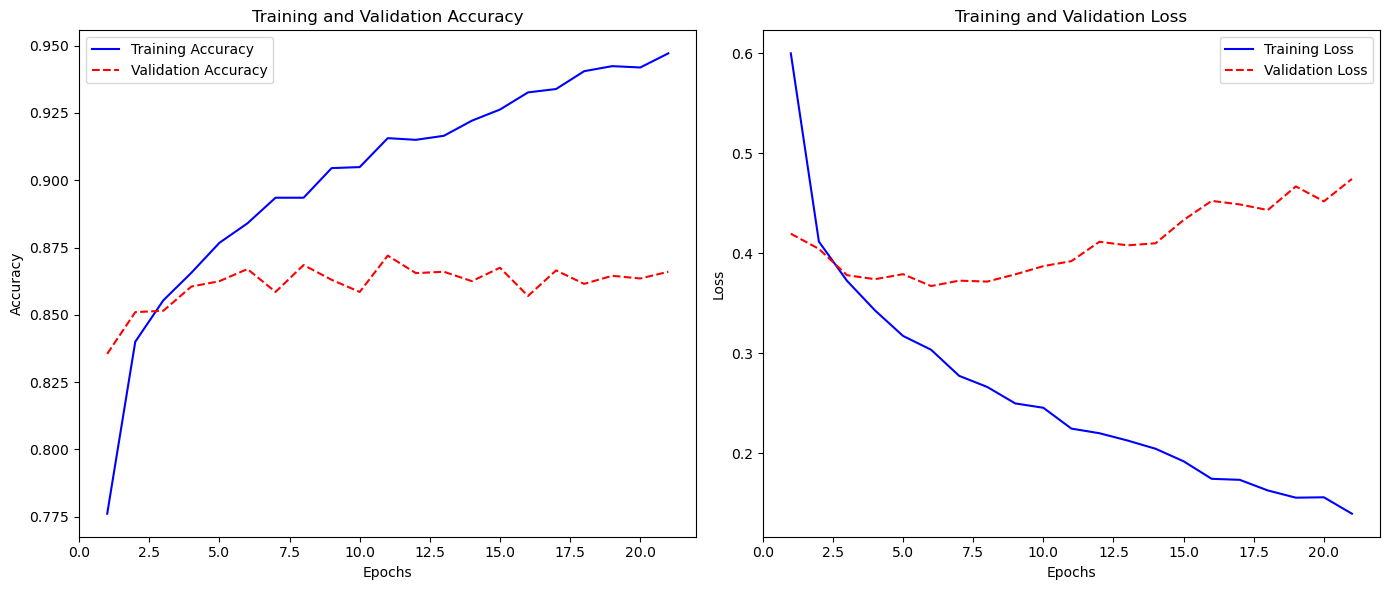

In [309]:
plot_training_history(history_fnn_tf_100)

## 2.3 CNN

In [245]:
def create_cnn_model(input_shape, num_classes):
    model_cnn = Sequential()
    model_cnn.add(Conv2D(32, (3, 3), activation='leaky_relu', input_shape=input_shape))
    model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
    model_cnn.add(Conv2D(64, (3, 3), activation='leaky_relu'))
    model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
    model_cnn.add(Flatten())
    model_cnn.add(Dense(256, activation='leaky_relu'))
    model_cnn.add(Dropout(0.5))
    model_cnn.add(BatchNormalization())
    model_cnn.add(Dense(128, activation='leaky_relu'))
    model_cnn.add(BatchNormalization())
    model_cnn.add(Dropout(0.3))
    model_cnn.add(Dense(64, activation='leaky_relu'))  # Second hidden layer
    model_cnn.add(BatchNormalization())
    model_cnn.add(Dropout(0.2))
    model_cnn.add(Dense(32, activation='leaky_relu'))
    model_cnn.add(BatchNormalization())
    model_cnn.add(Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification
    
    # Compile the model
    model_cnn.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model_cnn

In [246]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index].reshape(-1, 28, 28, 1), train_data_X[val_index].reshape(-1, 28, 28, 1)
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the CNN model
    model = create_cnn_model(input_shape=(28, 28, 1), num_classes=len(np.unique(train_data_y)))
    
    # Define EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=10,         # Stop if no improvement after 10 epochs
        restore_best_weights=True  # Restore weights from the best epoch
    )
    
    # Train the model with validation and early stopping
    history_cnn = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping]
    )
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Convert probabilities to class predictions
    
    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")


Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 1 Accuracy: 0.8875
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86       415
           1       0.99      0.97      0.98       379
           2       0.89      0.94      0.91       388
           3       0.93      0.91      0.92       405
           4       0.81      0.73      0.77       413

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

Confusion Matrix for Fold 1:
 [[371   0   7   7  30]
 [  2 369   1   4   3]
 [  2   0 364   2  20]
 [ 10   3   4 370  18]
 [ 67   0  32  13 301]]
Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 2 Accuracy: 0.8675
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80       398
           1       0.99      0.99      0.99       393
           2       0.87      0.92      0.89       425
           3       0.94      0.92      0.93       396
           4       0.73      0.71      0.72       388

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 2:
 [[317   0  16   6  59]
 [  2 388   0   3   0]
 [  6   0 390   3  26]
 [  8   2   6 363  17]
 [ 61   3  37  10 277]]
Training fold 3


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 3 Accuracy: 0.8765
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       399
           1       0.98      0.98      0.98       398
           2       0.90      0.87      0.89       366
           3       0.91      0.93      0.92       398
           4       0.78      0.76      0.77       439

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix for Fold 3:
 [[338   2   6   9  44]
 [  1 391   0   5   1]
 [  7   0 318   5  36]
 [  6   5   3 372  12]
 [ 62   2  25  16 334]]
Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 4 Accuracy: 0.8895
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.81      0.92      0.86       411
           1       0.98      0.98      0.98       414
           2       0.86      0.93      0.89       406
           3       0.94      0.94      0.94       396
           4       0.85      0.66      0.74       373

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.88      2000
weighted avg       0.89      0.89      0.89      2000

Confusion Matrix for Fold 4:
 [[380   2   6   5  18]
 [  3 405   0   5   1]
 [  7   2 376   2  19]
 [ 10   4   5 373   4]
 [ 68   1  49  10 245]]
Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 5 Accuracy: 0.8720
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.79      0.91      0.84       410
           1       0.98      0.98      0.98       363
           2       0.87      0.92      0.89       416
           3       0.88      0.95      0.91       410
           4       0.88      0.61      0.72       401

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 5:
 [[372   0   3  16  19]
 [  0 356   0   7   0]
 [ 13   0 382  11  10]
 [ 10   4   1 389   6]
 [ 76   4  55  21 245]]

Average Accuracy across 5 folds: 0.8786


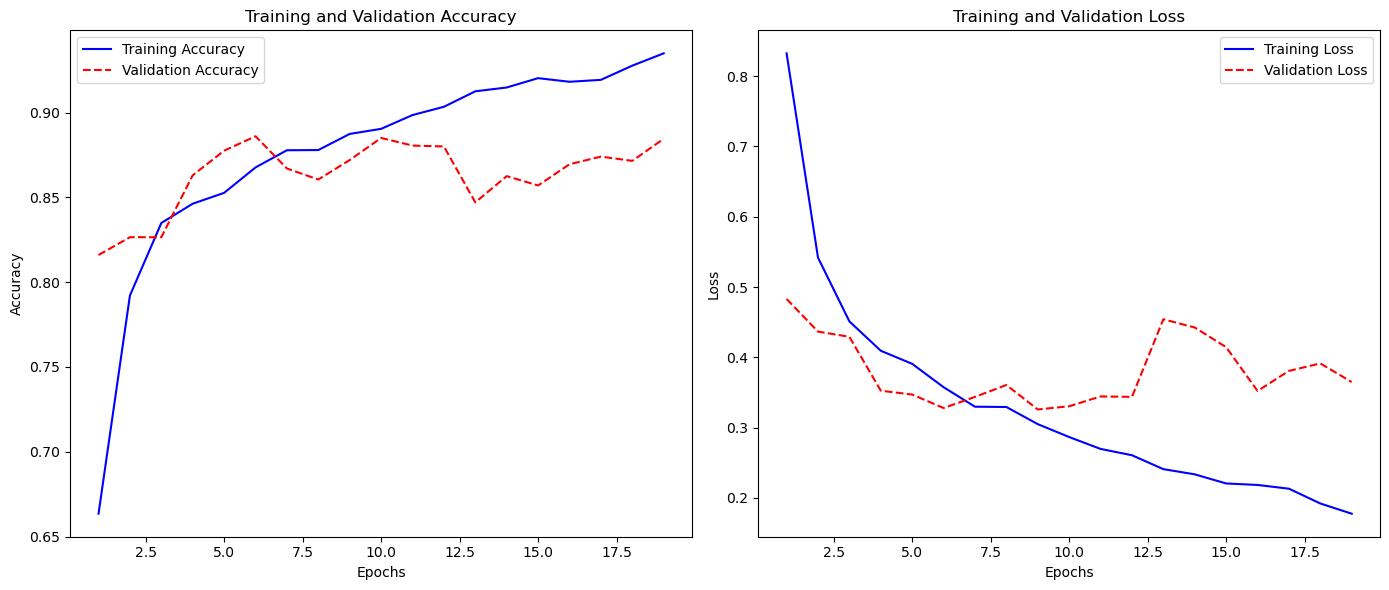

In [247]:
def plot_training_history(history):
    # Extract accuracy and loss values for both training and validation
    accuracy = history.history['accuracy']
    val_accuracy = history.history.get('val_accuracy', [])
    loss = history.history['loss']
    val_loss = history.history.get('val_loss', [])

    epochs = range(1, len(accuracy) + 1)

    # Plot Accuracy
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
    if val_accuracy:
        plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Show the plots
    plt.tight_layout()
    plt.show()
    
plot_training_history(history_cnn)

In [235]:

# Partial function for default Conv2D
DefaultConv2D = partial(tf.keras.layers.Conv2D, 
                        kernel_size=3, 
                        padding="same",
                        activation="leaky_relu", 
                        kernel_initializer="he_normal")

# Function to create CNN model
def create_cnn_from_book(input_shape, num_classes):
    model_book = tf.keras.Sequential([
        DefaultConv2D(filters=64, kernel_size=7, input_shape=input_shape),
        tf.keras.layers.MaxPool2D(),
        DefaultConv2D(filters=128),
        DefaultConv2D(filters=128),
        tf.keras.layers.MaxPool2D(),
        DefaultConv2D(filters=256),
        DefaultConv2D(filters=256),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units=128, activation="leaky_relu", kernel_initializer="he_normal"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(units=64, activation="leaky_relu", kernel_initializer="he_normal"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(units=num_classes, activation="softmax")
    ])
    model_book.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model_book


In [243]:
from keras.callbacks import EarlyStopping

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train = (train_data_X[train_index] / 255.0).reshape(-1, 28, 28, 1)  # Normalize and reshape for Conv2D input
    X_val = (train_data_X[val_index] / 255.0).reshape(-1, 28, 28, 1)      # Normalize and reshape for Conv2D input
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the CNN model
    model1 = create_cnn_from_book(input_shape=(28, 28, 1), num_classes=5)
    
    # Define EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=10,         # Stop training after 10 epochs with no improvement
        restore_best_weights=True  # Restore weights from the best epoch
    )
    
    # Train the model with early stopping
    history_book = model1.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),  # Validation data for early stopping
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping]
    )
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model1.predict(X_val), axis=1)  # Convert probabilities to class predictions
    
    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")


Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Fold 1 Accuracy: 0.8800
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.85      0.84      0.84       415
           1       0.99      0.98      0.98       379
           2       0.87      0.95      0.91       388
           3       0.90      0.90      0.90       405
           4       0.80      0.75      0.77       413

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix for Fold 1:
 [[347   0   6   9  53]
 [  1 370   0   6   2]
 [  4   0 369   7   8]
 [ 17   5   2 365  16]
 [ 39   0  46  19 309]]
Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Fold 2 Accuracy: 0.8690
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81       398
           1       1.00      0.99      0.99       393
           2       0.94      0.85      0.89       425
           3       0.88      0.94      0.91       396
           4       0.75      0.73      0.74       388

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 2:
 [[333   0   3  20  42]
 [  1 389   0   3   0]
 [ 12   0 360   9  44]
 [ 12   1   1 373   9]
 [ 68   0  19  18 283]]
Training fold 3


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Fold 3 Accuracy: 0.8785
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       399
           1       0.98      0.99      0.99       398
           2       0.90      0.86      0.88       366
           3       0.91      0.93      0.92       398
           4       0.80      0.77      0.78       439

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix for Fold 3:
 [[343   0   4  17  35]
 [  0 395   0   1   2]
 [ 12   1 314   2  37]
 [  5   6   7 369  11]
 [ 64   1  22  16 336]]
Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Fold 4 Accuracy: 0.8895
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.85      0.86      0.85       411
           1       1.00      0.98      0.99       414
           2       0.89      0.91      0.90       406
           3       0.92      0.96      0.94       396
           4       0.77      0.73      0.75       373

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

Confusion Matrix for Fold 4:
 [[352   0   3  10  46]
 [  0 405   3   6   0]
 [  6   0 370   4  26]
 [  5   1   2 379   9]
 [ 51   0  36  13 273]]
Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Fold 5 Accuracy: 0.8760
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.76      0.94      0.84       410
           1       0.99      0.98      0.98       363
           2       0.89      0.90      0.89       416
           3       0.90      0.96      0.93       410
           4       0.89      0.62      0.73       401

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.87      2000
weighted avg       0.88      0.88      0.87      2000

Confusion Matrix for Fold 5:
 [[384   0   3   9  14]
 [  2 354   0   7   0]
 [ 12   1 374  14  15]
 [ 15   1   0 392   2]
 [ 92   1  45  15 248]]

Average Accuracy across 5 folds: 0.8786


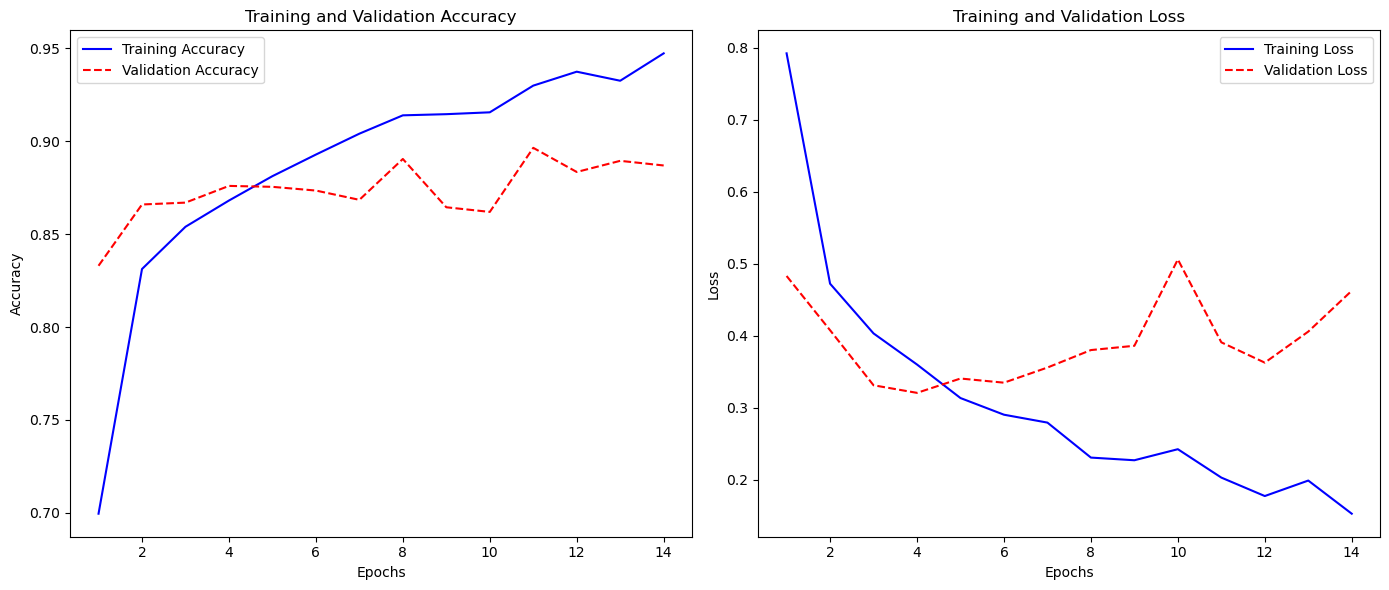

In [ ]:
def plot_training_history(history):
    # Extract accuracy and loss values for both training and validation
    accuracy = history.history['accuracy']
    val_accuracy = history.history.get('val_accuracy', [])
    loss = history.history['loss']
    val_loss = history.history.get('val_loss', [])

    epochs = range(1, len(accuracy) + 1)

    # Plot Accuracy
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
    if val_accuracy:
        plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Show the plots
    plt.tight_layout()
    plt.show()
    
plot_training_history(history_book)

# Final tests

Evaluate performance on fashion_test.npy. 

In [113]:
build_in_dt=tree.DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=10)
dt_from_scratch=DecisionTreeFromScratch(max_depth=10, min_leaf=10)
build_in_fnn=create_multiclass_model_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
fnn_from_scratch=create_multiclass_model_from_scratch_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
build_in_cnn=create_cnn_model(input_shape=train_data_X.reshape(-1, 28, 28, 1).shape[1:], num_classes=len(np.unique(train_data_y)))
cnn_from_book=create_cnn_from_book(input_shape=train_data_X.reshape(-1, 28, 28, 1).shape[1:], num_classes=len(np.unique(train_data_y)))

In [184]:
def plot_metrics(metrics):
    epochs = range(1, len(metrics['loss']) + 1)
    
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, metrics['loss'], 'r-', label='Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, metrics['accuracy'], 'b-', label='Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

def plot_training_history(history):
    # Extract accuracy and loss values for both training and validation
    accuracy = history.history['accuracy']
    val_accuracy = history.history.get('val_accuracy', [])
    loss = history.history['loss']
    val_loss = history.history.get('val_loss', [])

    epochs = range(1, len(accuracy) + 1)

    # Plot Accuracy
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
    if val_accuracy:
        plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Show the plots
    plt.tight_layout()
    plt.show()


## Test the tree models
### Skitlern model

Accuracy: 0.76
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       977
           1       0.92      0.92      0.92       995
           2       0.75      0.76      0.76       989
           3       0.82      0.80      0.81      1023
           4       0.59      0.58      0.58      1016

    accuracy                           0.76      5000
   macro avg       0.76      0.76      0.76      5000
weighted avg       0.76      0.76      0.76      5000

Confusion Matrix:
[[735   8  21  51 162]
 [  9 917  11  40  18]
 [ 31  15 753  19 171]
 [ 68  47  28 819  61]
 [157  13 187  71 588]]


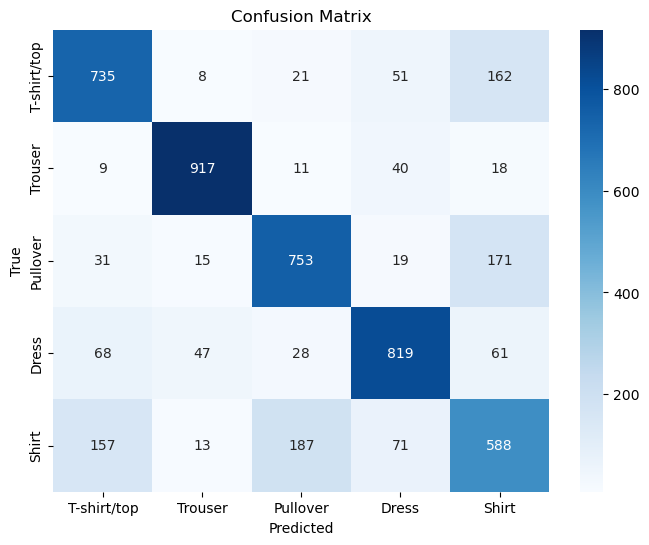

In [45]:
build_in_dt.fit(X_reduced_100,train_data_y)
predicted_y=build_in_dt.predict(test_X_reduced_100)

# Evaluate accuracy
accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix1 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix1)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Our implemntation

Accuracy: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73      1104
           1       0.92      0.95      0.94       963
           2       0.79      0.76      0.78      1042
           3       0.86      0.78      0.82      1108
           4       0.51      0.65      0.57       783

    accuracy                           0.77      5000
   macro avg       0.77      0.77      0.77      5000
weighted avg       0.78      0.77      0.78      5000

Confusion Matrix:
[[772  11  40  79 202]
 [  8 918   8  23   6]
 [ 28  10 794  11 199]
 [ 80  48  29 865  86]
 [112  13 129  22 507]]


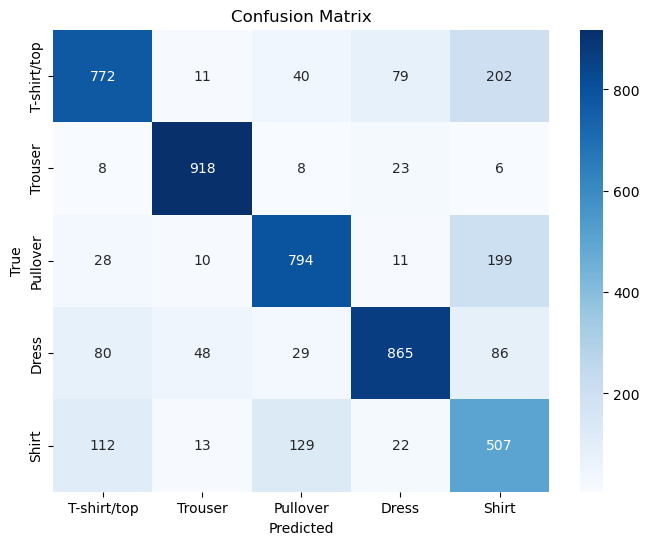

In [46]:
dt_from_scratch.fit(X_reduced_100,train_data_y)
predicted_y=dt_from_scratch.predict(test_X_reduced_100)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix2 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix2)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix2, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Test the Feed-forward neural networks models
### Tensorflow implementation

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9478 - loss: 0.1352
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9522 - loss: 0.1241
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9592 - loss: 0.1029
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9591 - loss: 0.1106
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9659 - loss: 0.0951
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9559 - loss: 0.1118
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9620 - loss: 0.0999
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9627 - loss: 0.0955
Epoch 9/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9547 - loss: 0.1172
Epoch 10/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9609 - loss: 0.1026
Epoch 11/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9639 - loss: 0.0984
Epoch 12/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

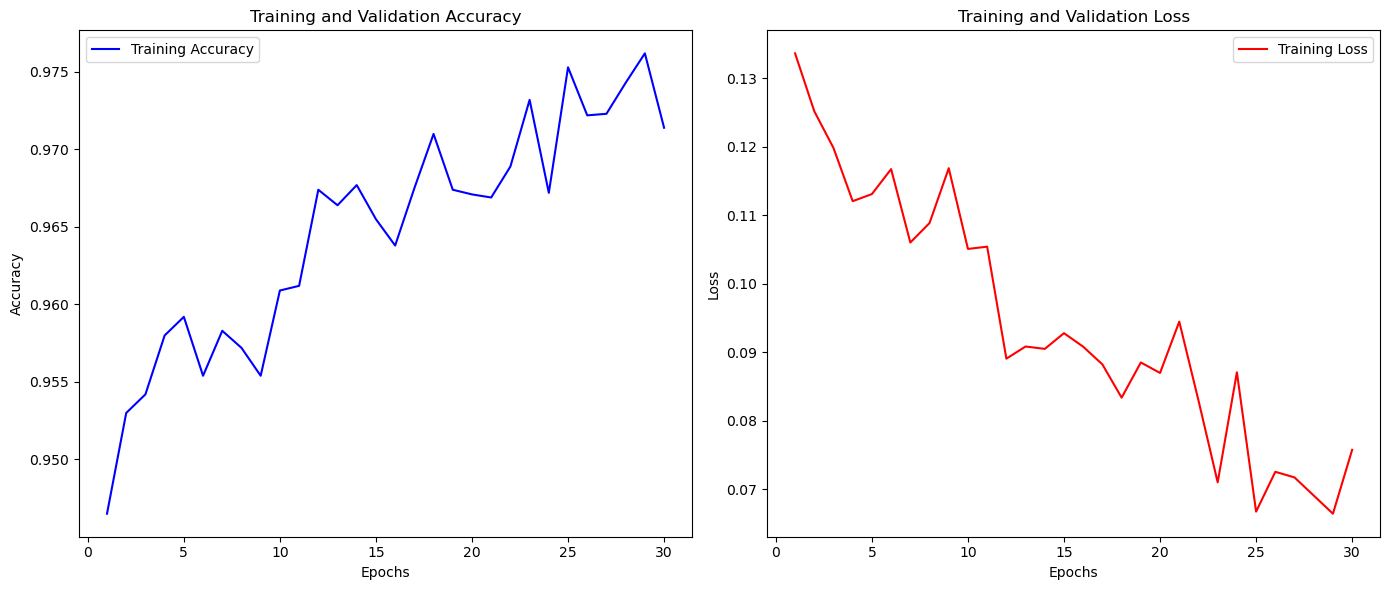

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.82      0.77       886
           1       0.96      0.99      0.98       977
           2       0.90      0.75      0.82      1210
           3       0.90      0.86      0.88      1049
           4       0.64      0.73      0.68       878

    accuracy                           0.83      5000
   macro avg       0.83      0.83      0.83      5000
weighted avg       0.84      0.83      0.83      5000

Confusion Matrix:
[[730   2  17  22 115]
 [  3 964   2   7   1]
 [ 83   6 904  31 186]
 [ 51  20  21 900  57]
 [133   8  56  40 641]]


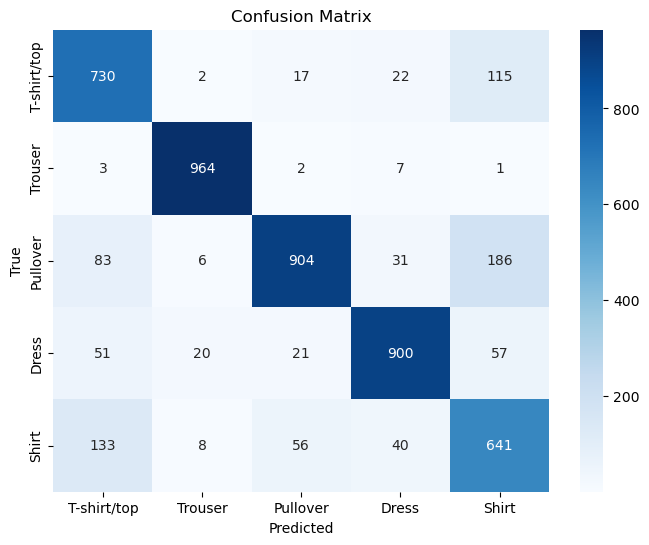

In [ ]:

history1=build_in_fnn.fit(train_data_X, train_data_y, epochs=50, batch_size=32)
plot_training_history(history1)
predicted_y=np.argmax(build_in_fnn.predict(test_data_X), axis=1)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix3 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix3)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix3, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Our implemntation

Accuracy: 0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       930
           1       0.95      0.97      0.96       979
           2       0.81      0.80      0.80      1015
           3       0.86      0.87      0.87       991
           4       0.66      0.61      0.64      1085

    accuracy                           0.80      5000
   macro avg       0.80      0.81      0.80      5000
weighted avg       0.80      0.80      0.80      5000

Confusion Matrix:
[[725   3  16  38 148]
 [  6 949   0  17   7]
 [ 26  17 809  13 150]
 [ 51  24  20 864  32]
 [192   7 155  68 663]]


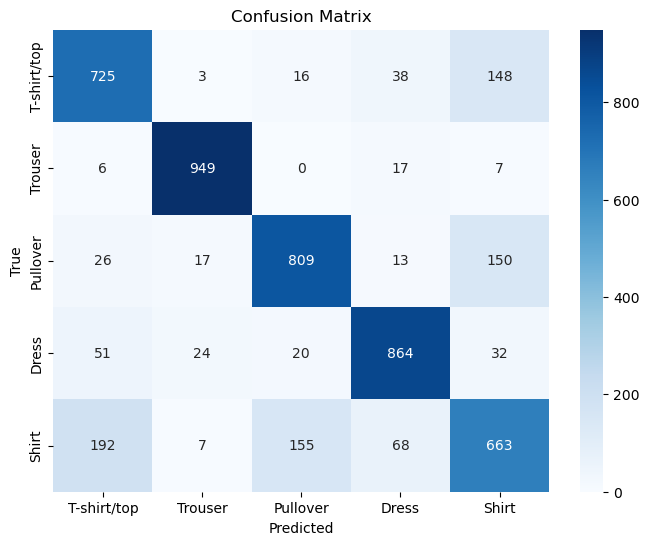

In [51]:
y_train = one_hot_encode(train_data_y, 5).T
fnn_from_scratch.fit(train_data_X.T, y_train, epochs=100, batch_size=32)
plot_metrics(fnn_from_scratch.metrics)
predicted_y=np.argmax(fnn_from_scratch.predict(test_data_X.T), axis=0)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix4 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix4)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix4, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Test Convolutional neural network

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9643 - loss: 0.1017
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9658 - loss: 0.0969
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9619 - loss: 0.1032
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9628 - loss: 0.1089
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9678 - loss: 0.0892
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9732 - loss: 0.0773
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9697 - loss: 0.0812
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9727 - loss: 0.0773
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9694 - loss: 0.0800
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9732 - loss: 0.0650


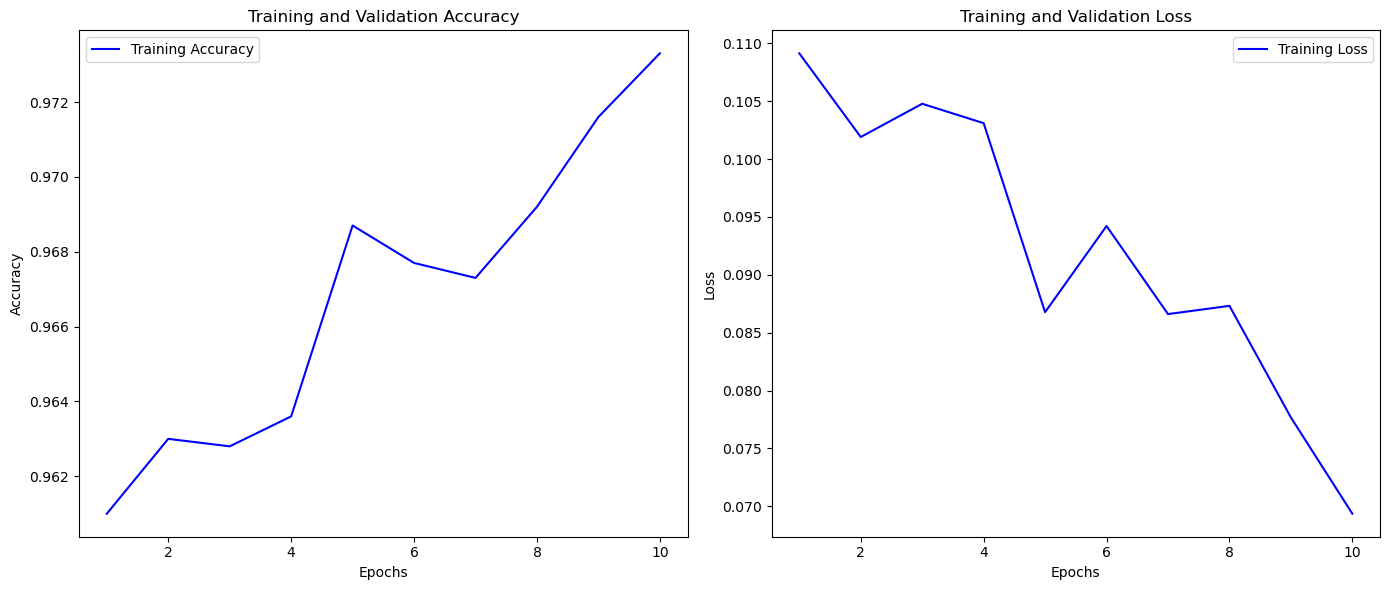

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.870
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       910
           1       0.98      0.98      0.98       993
           2       0.87      0.88      0.87       991
           3       0.93      0.91      0.92      1017
           4       0.79      0.72      0.75      1089

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000

Confusion Matrix:
[[789   2  11   8 100]
 [  4 978   1   8   2]
 [ 32   1 870  10  78]
 [ 27  16  12 927  35]
 [148   3 106  47 785]]


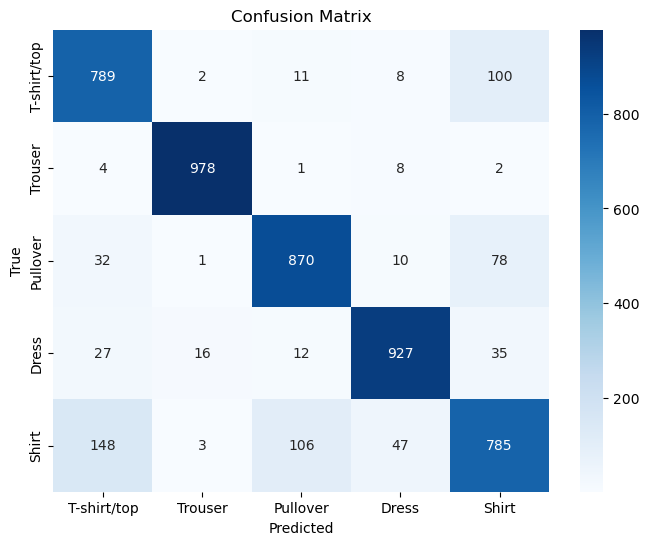

In [251]:
history3=build_in_cnn.fit(train_data_X.reshape(-1, 28, 28,1), train_data_y, epochs=10, batch_size=32, verbose=1)
plot_training_history(history3)
predicted_y=np.argmax(build_in_cnn.predict(test_data_X.reshape(-1, 28, 28,1)), axis=1)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.3f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix5 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix5)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix5, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()